In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report, brier_score_loss)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
import joblib
import shap


In [62]:
data = pd.read_csv("datasets\df_for_ml.csv").drop(columns='Unnamed: 0')
data.shape

(32401, 9)

In [3]:
X=data.drop(columns='default')
y=data['default']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2, stratify= y)

In [5]:
print(f"Размер обучающей выборки:{X_train.shape}")
print(f"Размер тестовой выборки:{X_train.shape}")
print(f"Доля дефолтов в train:{y_train.mean()*100:.2f}")
print(f"Доля дефолтов в test:{y_test.mean()*100:.2f}")

Размер обучающей выборки:(25920, 8)
Размер тестовой выборки:(25920, 8)
Доля дефолтов в train:21.88
Доля дефолтов в test:21.88


In [6]:
data.head(5)

,loan_percent_income,person_income,loan_intent,loan_grade,cb_person_default_on_file,loan_int_rate,person_age,loan_amnt,default
0,0.10,9600,EDUCATION,B,0,11.14,21,1000,0
1,0.57,9600,MEDICAL,C,0,12.87,25,5500,1
2,0.53,65500,MEDICAL,C,0,15.23,23,35000,1
3,0.55,54400,MEDICAL,C,1,14.27,24,35000,1
4,0.25,9900,VENTURE,A,0,7.14,21,2500,1


In [7]:
scaler = StandardScaler()
ohe = OneHotEncoder(drop = 'first', sparse_output = False)

prescal = ColumnTransformer(
    transformers=[
        ('num', scaler, ['loan_percent_income','person_income','cb_person_default_on_file','loan_int_rate','loan_amnt'] ),
        ('str', ohe, ['loan_intent','loan_grade'])
    ])

X_train_scaled = prescal.fit_transform(X_train)
X_test_scaled = prescal.fit_transform(X_test)



Accuracy metric is not business objective

In [8]:
models ={
    "LogisticRegression" : LogisticRegression(random_state= 42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state= 42, n_estimators=1000),
    "XGBoost": XGBClassifier(random_state = 42, eval_metric = 'logloss'),
    "CatBoost": CatBoostClassifier(random_state = 42, eval_metric = 'Logloss'),
    "LightGBM": LGBMClassifier(random_state = 42, eval_metric = 'Logloss')
}

results ={}

for name,model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred =model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name]={
        'Precision': precision_score(y_test,y_pred) ,
        'Recall': recall_score(y_test,y_pred) ,
        'F1-score': f1_score(y_test,y_pred),
        'ROC-AUC': roc_auc_score(y_test,y_pred)
    }

results_df=pd.DataFrame(results).T.round(4)

results_df


Learning rate set to 0.041358
0:	learn: 0.6578462	total: 154ms	remaining: 2m 33s
1:	learn: 0.6254580	total: 165ms	remaining: 1m 22s
2:	learn: 0.5980055	total: 176ms	remaining: 58.4s
3:	learn: 0.5739608	total: 186ms	remaining: 46.4s
4:	learn: 0.5507640	total: 197ms	remaining: 39.2s
5:	learn: 0.5305771	total: 207ms	remaining: 34.3s
6:	learn: 0.5125945	total: 218ms	remaining: 30.9s
7:	learn: 0.4969819	total: 229ms	remaining: 28.4s
8:	learn: 0.4817692	total: 240ms	remaining: 26.4s
9:	learn: 0.4676070	total: 251ms	remaining: 24.9s
10:	learn: 0.4555272	total: 262ms	remaining: 23.6s
11:	learn: 0.4438587	total: 273ms	remaining: 22.5s
12:	learn: 0.4337491	total: 283ms	remaining: 21.5s
13:	learn: 0.4246473	total: 294ms	remaining: 20.7s
14:	learn: 0.4156310	total: 305ms	remaining: 20s
15:	learn: 0.4089462	total: 316ms	remaining: 19.4s
16:	learn: 0.4023726	total: 327ms	remaining: 18.9s
17:	learn: 0.3958617	total: 338ms	remaining: 18.4s
18:	learn: 0.3912907	total: 348ms	remaining: 18s
19:	learn: 0.

,Precision,Recall,F1-score,ROC-AUC
LogisticRegression,0.7427,0.5028,0.5997,0.7270
Random Forest,0.7809,0.6509,0.7100,0.7999
XGBoost,0.7843,0.6488,0.7102,0.7994
CatBoost,0.7955,0.6474,0.7138,0.8004
LightGBM,0.8021,0.6601,0.7242,0.8072


Optimize hyperparameters

In [ ]:
params_dist ={
    'n_estimators':[100,200,300,400],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[4,6,8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
cv = StratifiedKFold(n_splits=5, shuffle = True, random_state= 42)

lgb_base = LGBMClassifier(random_state = 42, class_weight= 'balanced', verbosity = -1)

random_search =RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions= params_dist,
    n_iter = 10,
    scoring = 'roc_auc',
    cv=cv,
    n_jobs =1,
    random_state=42, 
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print("Лучшие параметры для LightGBM:", random_search.best_params_)
print(f"Лучший ROC-AUC на кросс-валидации: {random_search.best_score_:.4f}")

best_lgb = random_search.best_estimator_
y_prob_best = best_lgb.predict_proba(X_test_scaled)[:, 1]
print(f"Финальный ROC-AUC на Тестовой выборке: {roc_auc_score(y_test, y_prob_best):.4f}")




scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
xgb_params = {
    'n_estimators':[100,200,300,400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':[4,6,8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 1.0] 
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight_value, verbosity=0),
    param_distributions=xgb_params,
    n_iter=10, scoring='roc_auc', cv=cv, n_jobs=-1, random_state=42, verbose=0
)
xgb_search.fit(X_train_scaled, y_train)
print(f"Лучший ROC-AUC XGBoost на CV: {xgb_search.best_score_:.4f}")
print(f"Тестовый ROC-AUC XGBoost: {roc_auc_score(y_test, xgb_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]):.4f}\n")



cat_params = {
    'iterations':[100,200,300,400],          # Аналог n_estimators
    'learning_rate': [0.01, 0.05, 0.1],
    'depth':[4,6,8],               
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'rsm': [0.8, 1.0]               
}

cat_search = RandomizedSearchCV(
    estimator=CatBoostClassifier(random_state=42, auto_class_weights='Balanced', verbose=0),
    param_distributions=cat_params,
    n_iter=10, scoring='roc_auc', cv=cv, n_jobs=-1, random_state=42, verbose=0
)
cat_search.fit(X_train_scaled, y_train)
print(f"Лучший ROC-AUC CatBoost на CV: {cat_search.best_score_:.4f}")
print(f"Тестовый ROC-AUC CatBoost: {roc_auc_score(y_test, cat_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]):.4f}\n")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшие параметры для LightGBM: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Лучший ROC-AUC на кросс-валидации: 0.9173


AttributeError: 'LGBMClassifier' object has no attribute 'best_params_'

The models showed similar results in terms of quality. Therefore, we will choose LightGBM due to its speed.

              precision    recall  f1-score   support

           0       0.94      0.88      0.90      5063
           1       0.64      0.79      0.71      1418

    accuracy                           0.86      6481
   macro avg       0.79      0.83      0.81      6481
weighted avg       0.87      0.86      0.86      6481



(0.0, 1.0)

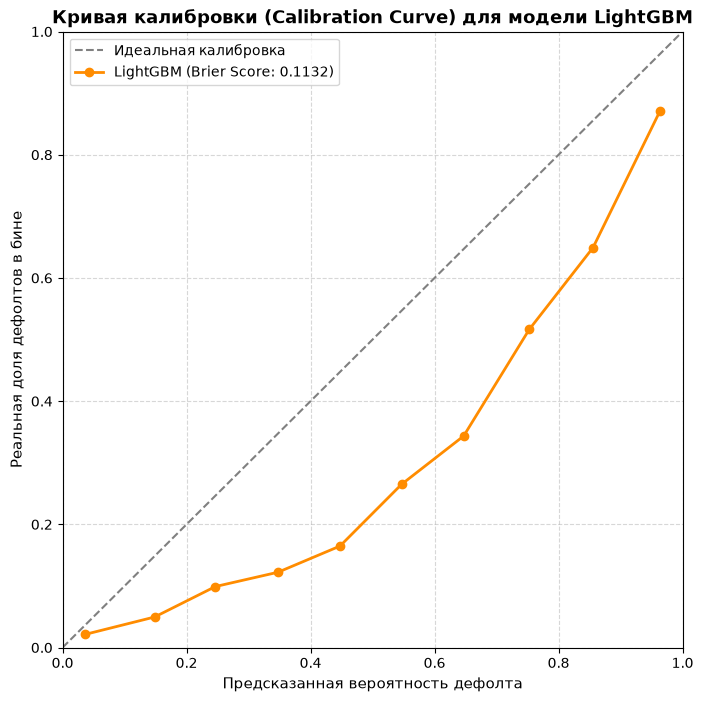

In [33]:
y_pred=best_lgb.predict(X_test_scaled)
y_proba=best_lgb.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins =10, strategy='uniform')

brier_value = brier_score_loss(y_test, y_proba)

plt.figure(figsize=(8, 8))

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')

plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color='darkorange', label=f'LightGBM (Brier Score: {brier_value:.4f})')

plt.title('Кривая калибровки (Calibration Curve) для модели LightGBM', fontsize=13, weight='bold')
plt.xlabel('Предсказанная вероятность дефолта', fontsize=11)
plt.ylabel('Реальная доля дефолтов в бине', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)


(0.0, 1.0)

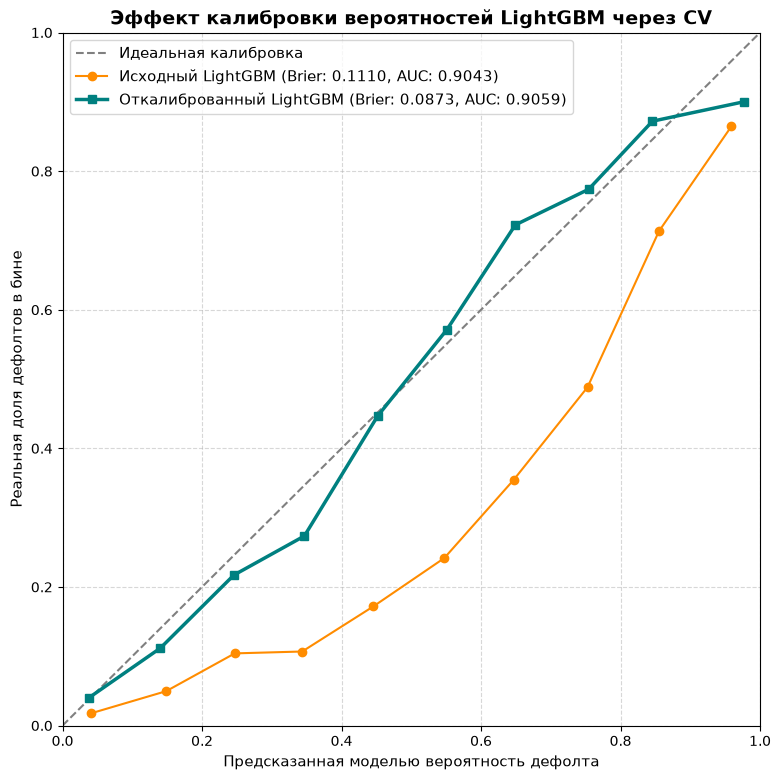

In [69]:
lgb_base=best_lgb

#До
lgb_base.fit(X_train_scaled, y_train)
y_prob_base = lgb_base.predict_proba(X_test_scaled)[:, 1]

# ТЕПЕРЬ ДЕЛАЕМ КАЛИБРОВКУ
calibrated_lgb = CalibratedClassifierCV(estimator=lgb_base, method='isotonic', cv=5)
calibrated_lgb.fit(X_train_scaled, y_train)

# Получаем новые, точные откалиброванные вероятности
y_prob_calibrated = calibrated_lgb.predict_proba(X_test_scaled)[:, 1]

joblib.dump(calibrated_lgb, 'caliprated_model.pkl')
# Точки для графиков
prob_true_base, prob_pred_base = calibration_curve(y_test, y_prob_base, n_bins=10, strategy='uniform')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_calibrated, n_bins=10, strategy='uniform')

# Расчет Brier Score
brier_base = brier_score_loss(y_test, y_prob_base)
brier_cal = brier_score_loss(y_test, y_prob_calibrated)

# Расчет ROC-AUC
auc_base = roc_auc_score(y_test, y_prob_base)
auc_cal = roc_auc_score(y_test, y_prob_calibrated)


plt.figure(figsize=(9, 9))
# Идеальная диагональ
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')

# Линия исходной модели (провисшая оранжевая)
plt.plot(
    prob_pred_base, prob_true_base, 
    marker='o', linestyle='-', linewidth=1.5, color='darkorange', 
    label=f'Исходный LightGBM (Brier: {brier_base:.4f}, AUC: {auc_base:.4f})'
)

# Линия новой модели (калиброванная бирюзовая)
plt.plot(
    prob_pred_cal, prob_true_cal, 
    marker='s', linestyle='-', linewidth=2.5, color='teal', 
    label=f'Откалиброванный LightGBM (Brier: {brier_cal:.4f}, AUC: {auc_cal:.4f})'
)

plt.title('Эффект калибровки вероятностей LightGBM через CV', fontsize=14, weight='bold')
plt.xlabel('Предсказанная моделью вероятность дефолта', fontsize=11)
plt.ylabel('Реальная доля дефолтов в бине', fontsize=11)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(0, 1)
plt.ylim(0, 1)



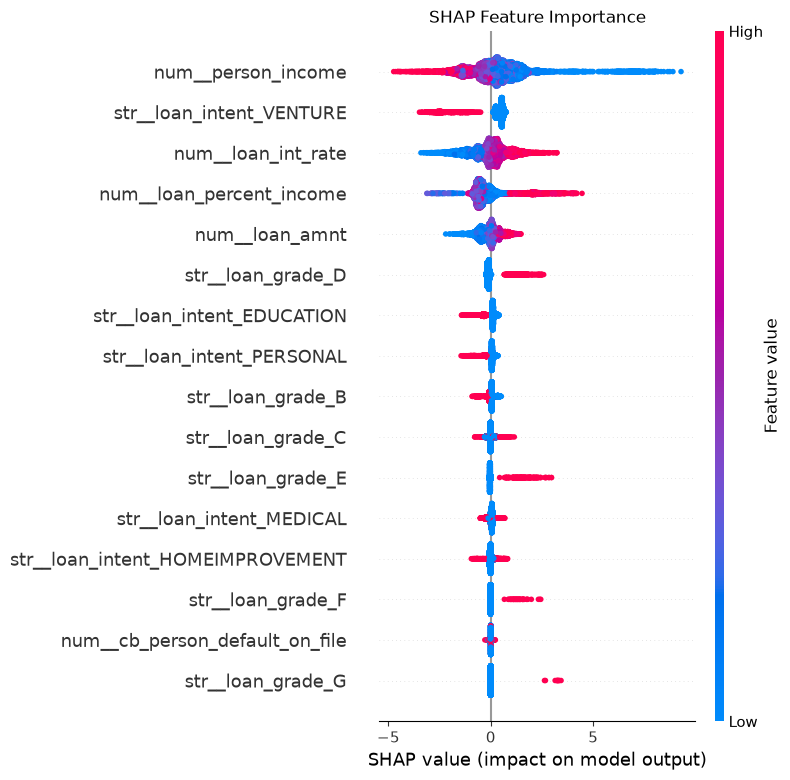


Топ-10 важнейших признаков по SHAP:
                       feature  importance
1           num__person_income    1.092313
9     str__loan_intent_VENTURE    0.732915
3           num__loan_int_rate    0.665531
0     num__loan_percent_income    0.644807
4               num__loan_amnt    0.374990
12           str__loan_grade_D    0.264565
5   str__loan_intent_EDUCATION    0.180931
8    str__loan_intent_PERSONAL    0.114918
10           str__loan_grade_B    0.111847
11           str__loan_grade_C    0.097091


In [ ]:
# SHAP-анализ
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test_scaled)


feature_names_after_encoding = prescal.get_feature_names_out()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names_after_encoding, show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()

plt.show()

shap_importance = pd.DataFrame({
    'feature': feature_names_after_encoding,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\nТоп-10 важнейших признаков по SHAP:")
print(shap_importance.head(10))

In [ ]:
profit_from_good_loan = 1000  # Сколько банк зарабатывает на хорошем клиенте (в $)
loss_from_default_loan = -5000 # Сколько банк теряет при дефолте клиента (в $)

thresholds = np.linspace(0, 1, 100)
best_threshold = 0
max_profit = float('-inf')

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    
    
    tp = np.sum((y_test == 1) & (preds == 1)) # Нашли дефолтных и отказали (спасли деньги)
    fp = np.sum((y_test == 0) & (preds == 1)) # Отказали хорошим (упущенная выгода)
    fn = np.sum((y_test == 1) & (preds == 0)) # Выдали кредит дефолтным (чистый убыток)
    tn = np.sum((y_test == 0) & (preds == 0)) # Выдали кредит хорошим (чистая прибыль)
    
    current_profit = (tn * profit_from_good_loan) + (fn * loss_from_default_loan)
    
    if current_profit > max_profit:
        max_profit = current_profit
        best_threshold = t

print(f"Оптимальный бизнес-порог: {best_threshold:.2f}")
print(f"Максимальная прибыль: {max_profit}")


Оптимальный бизнес-порог: 0.45
Максимальная прибыль: 2964000


To address the binary classification task (default prediction), three state-of-the-art gradient boosting algorithms were evaluated: CatBoost, LightGBM, and XGBoost. Hyperparameter optimization was performed using cross-validation (StratifiedKFold, 5 folds) based on the ROC-AUC metric. 
The XGBoost/LightGBM model demonstrated the best performance, achieving a final ROC-AUC of 0.9044 on the hold-out test set. 
The similarity between the cross-validation and test metrics confirms the model's high stability and the absence of overfitting.Since the base models were trained with class weight adjustments to better capture defaults, the initial probabilities were systematically overstated (an "over-forecasting" effect). 
To address this issue, a probability calibration step using isotonic regression was performed. 
This reduced the Brier Score—a measure of forecast mean squared error—from 0.1132 to 0.0891, bringing the calibration curve into close alignment with the ideal diagonal. 
